*Content of this notebook*: 
This notebook contains some additional figures requested during the process of the revision. 

In [1]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
CommonOperations         C:\Users\aleja\anaconda3\envs\CommonOperations
Palantir_Env1            C:\Users\aleja\anaconda3\envs\Palantir_Env1
scRNA_env                C:\Users\aleja\anaconda3\envs\scRNA_env
scvelo_env               C:\Users\aleja\anaconda3\envs\scvelo_env
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv               *  C:\Users\aleja\anaconda3\envs\textenv



In [2]:
import os

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt
import seaborn as sns
sc.settings.verbosity = 3                
sc.logging.print_versions()  
sc.settings.set_figure_params(dpi=80, facecolor='white')

-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         8.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        23.2.0
attrs                       23.2.0
babel                       2.14.0
backcall                    0.2.0
bottleneck                  1.3.7
brotli                      NA
certifi                     2024.08.30
cffi                        1.16.0
chardet                     5.2.0
charset_normalizer          3.3.2
cloudpickle                 3.0.0
colorama                    0.4.6
comm                        0.2.1
cycler                      0.12.1
cython_runtime              NA
cytoolz                     0.12.3
dask                        2024.2.0
dateutil                    2.8.2
debugpy                     1.8.1
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.0
executing                   2.0.1
fastjsonschema              NA

## PART 1: CDH11 

### Loading data 

Plot the expression of CDH11 using a violin plot in the integrated (Harmony) dataset

In [4]:
Integrated = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered_anno.h5ad')

In [5]:
adata_subset = Integrated[Integrated.obs['annotation'].isin(['NMP', 'pPSM','aPSM',"Somite_1",
                     'Somite_2', 'Head_Mesoderm'])].copy() # we subset the most relevant clusters for further analysis 

In [6]:
adata_subset.obs['annotation_short'] = (
    adata_subset.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite"}.get(x, x))
    .astype("category")
)

In [7]:
adata_subset.obs['annotation_short'] = adata_subset.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm'])

['CDH11']
CDH11


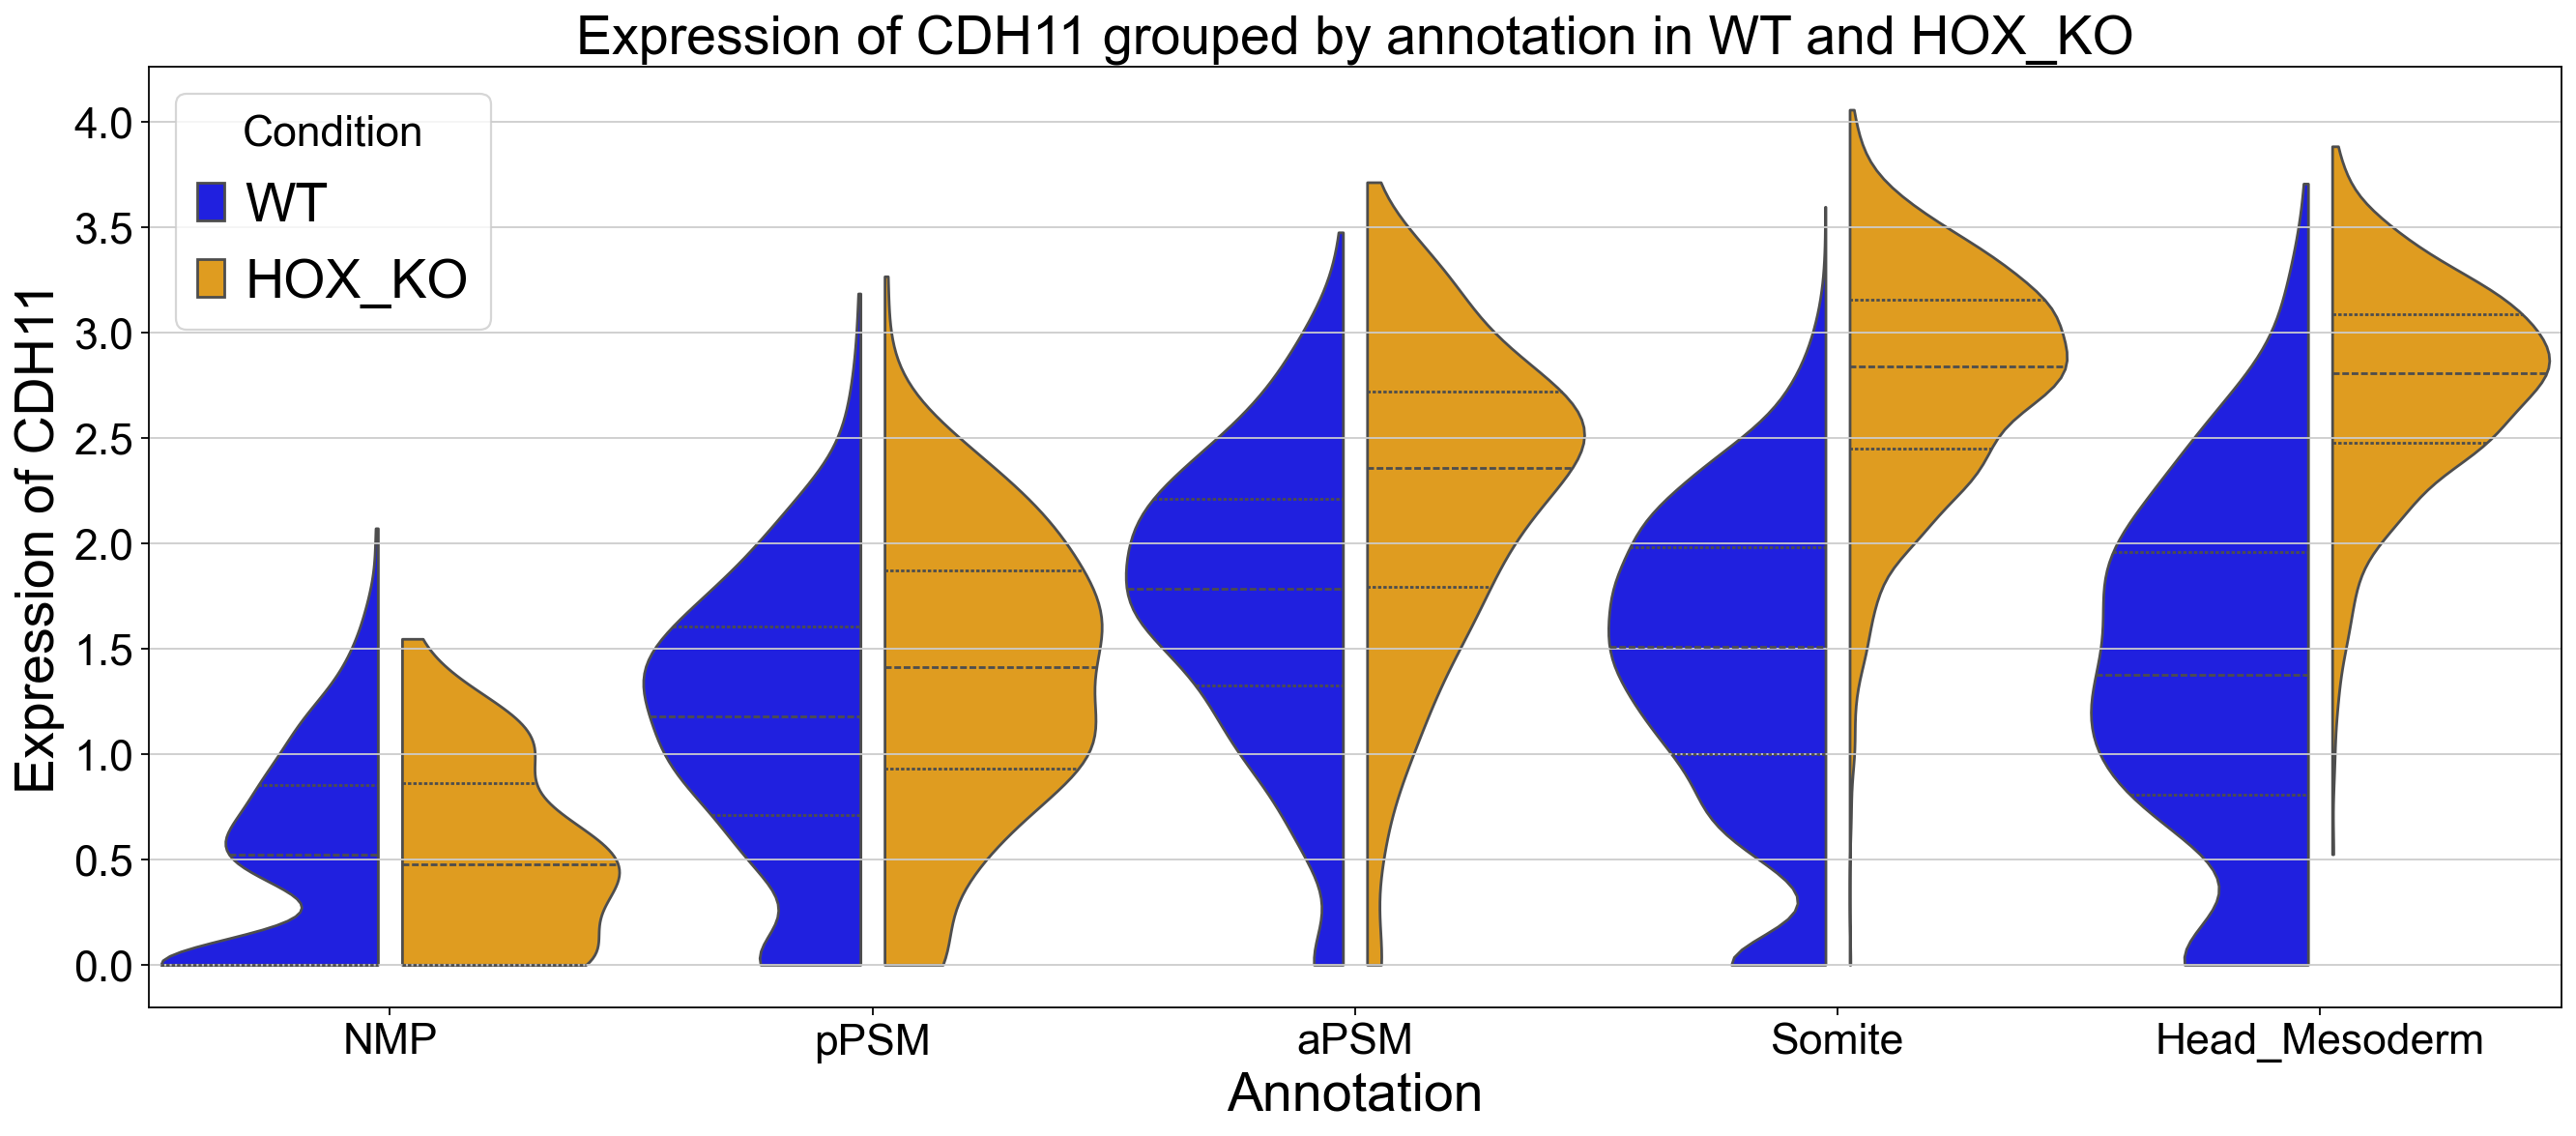

In [8]:
#Split plot of lognorm expression :
gene_of_interest = ["CDH11"]

print(gene_of_interest)

# Specify the two conditions you want to compare
condition_1 = 'WT'
condition_2 = 'HOX_KO'

# Filter the AnnData object to include only the two conditions
adata_filtered = adata_subset[adata_subset.obs['sample'].isin([condition_1, condition_2])]

# Define the order of conditions for plotting
condition_order = [condition_1, condition_2]

# Loop through each gene in the list
for gene in gene_of_interest:
    print(gene)
    # Ensure the gene exists in the data
    if gene not in adata_filtered.var_names:
        print(f"Gene {gene} not found in the dataset.")
        continue
    
    # Extract expression data for the gene (adata.X contains lognorm values)
    gene_expression = adata_filtered[:, gene].X
    
    # Create a DataFrame with the expression data, condition, and annotation labels
    expression_df = pd.DataFrame({
        'expression': gene_expression.A.flatten() if hasattr(gene_expression, 'A') else gene_expression.flatten(),
        'condition': adata_filtered.obs['sample'],
        'annotation': adata_filtered.obs["annotation_short"]
    })
    
    # Set up the matplotlib figure
    plt.figure(figsize=(20, 8))
    
    # Create a split plot using seaborn, grouped by annotation
    sns.violinplot(x='annotation', y='expression', hue='condition', data=expression_df, inner="quart",gap=0.1, density_norm ="width",
                   split=True, palette={condition_1: 'blue', condition_2: 'orange'}, hue_order=condition_order, width=1, cut=0)
    
    # Customize the plot
    plt.title(f"Expression of {gene} grouped by annotation in {condition_1} and {condition_2}", fontsize=25)
    plt.xlabel("Annotation", fontsize=25)
    plt.ylabel(f"Expression of {gene}",fontsize=25)
    plt.legend(title='Condition',title_fontsize=20, fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    # Save the figure before displaying it
    file_name = f'figures/20260107{gene}_expression_violinplot_{condition_1}_vs_{condition_2}.pdf'
    #plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

## PART 2: Generate Violin plot of Additional genes in NMP cluster

 All genotypes included

In [9]:
NMP_violin = adata_subset[adata_subset.obs['annotation_short'] == 'NMP',:].copy()

In [10]:
NMP_violin.obs['sample'] = NMP_violin.obs['sample'].cat.reorder_categories(['WT','HOXD_KO','HOXCD_KO','HOXBCD_KO','HOX_KO'])

In [11]:
list_genes2 = [ "SOX2","TBXT"]

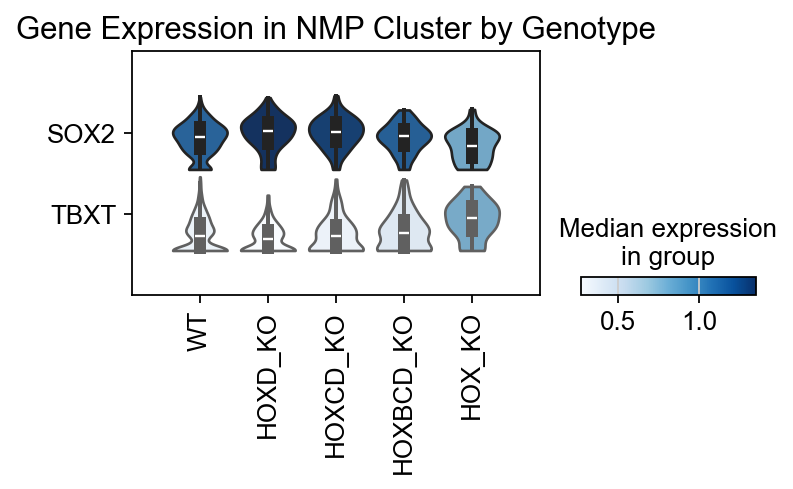

In [12]:
# Create a split violin plot
sc.pl.stacked_violin(
    adata=NMP_violin,
    var_names=list_genes2,
    groupby='sample',  
    swap_axes=True,  # Horizontal layout for better readability
    figsize=(5, len(list_genes2) * 1),  # Dynamically adjust figure size
    title="Gene Expression in NMP Cluster by Genotype",
    density_norm="width",
    inner="box",
    linewidth=1.2,
    #save="20260107_NMP_SOX2TBXT_stackedviolin_allgenotypes.pdf"
)

In [13]:
list_genes1 = [ "SOX2","TBXT", "FGF4", "FGF17", "BMP7", "TGFB1", "WNT3A", "WNT5A","WNT8A", "RSPO3", "DRAXIN", "SFRP2"]

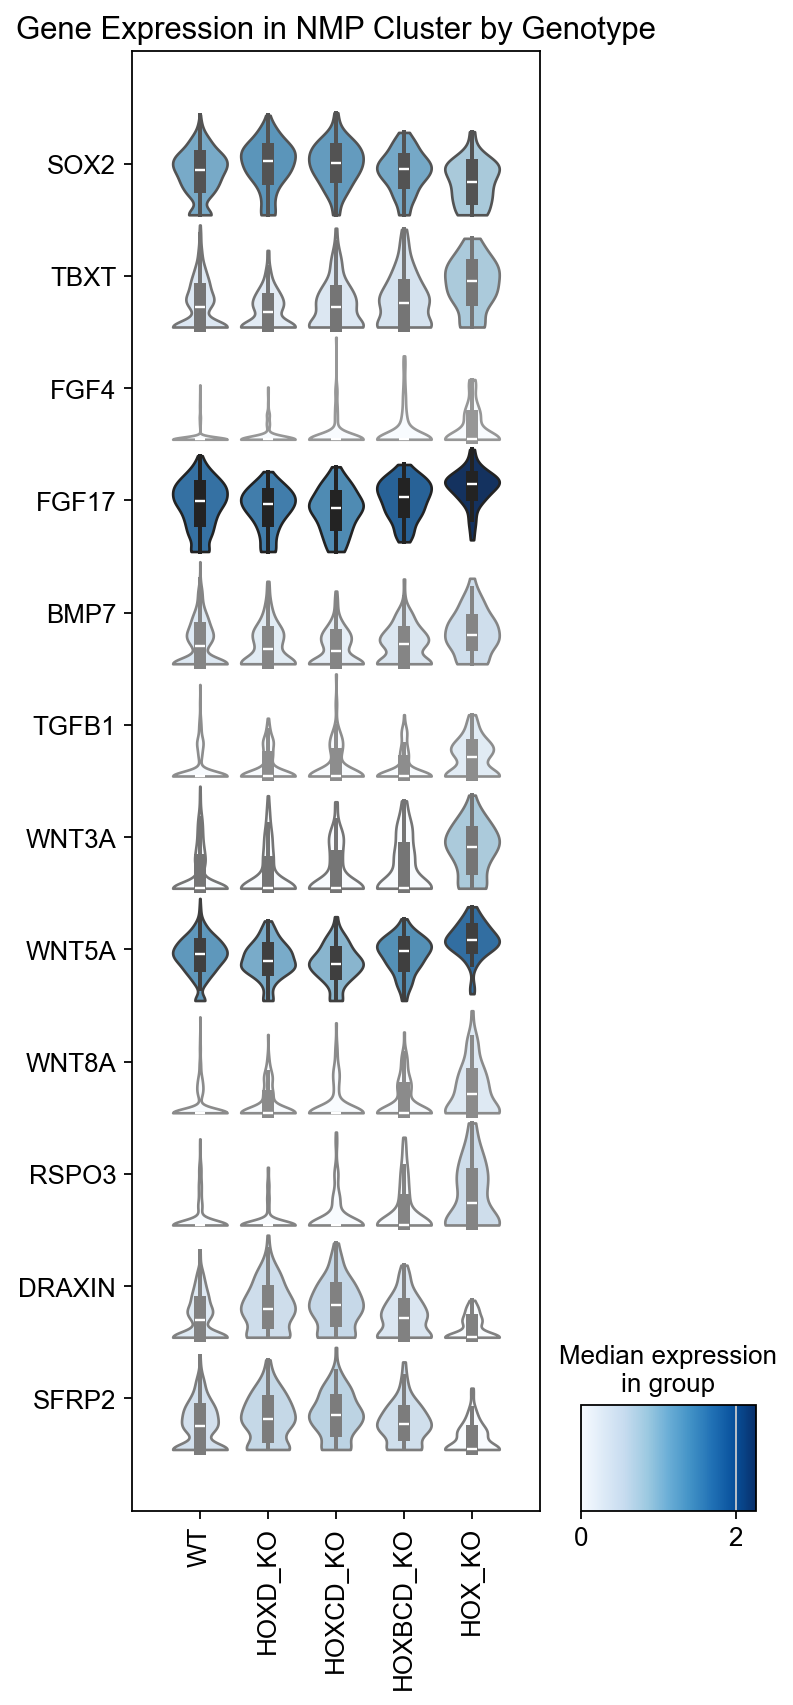

In [14]:
# Create a split violin plot
sc.pl.stacked_violin(
    adata=NMP_violin,
    var_names=list_genes1,
    groupby='sample',  
    swap_axes=True,  # Horizontal layout for better readability
    figsize=(5, len(list_genes1) * 1),  # Dynamically adjust figure size
    title="Gene Expression in NMP Cluster by Genotype",
    density_norm="width",
    inner="box",
    linewidth=1.2,
    #save="20260107_NMP_DEGgenes_stackedviolin_allgenotypes.pdf"
)